In [29]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [30]:
model = ResNet50(weights='imagenet')


In [31]:
!wget -O /content/dog.png https://images.dog.ceo/breeds/hound-afghan/n02088094_1003.jpg


--2026-06-05 15:54:44--  https://images.dog.ceo/breeds/hound-afghan/n02088094_1003.jpg
Resolving images.dog.ceo (images.dog.ceo)... 104.21.17.246, 172.67.178.228, 2606:4700:3034::6815:11f6, ...
Connecting to images.dog.ceo (images.dog.ceo)|104.21.17.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36593 (36K) [image/jpeg]
Saving to: ‘/content/dog.png’

/content/dog.png    100%[===================>]  35.74K  --.-KB/s    in 0s      

2026-06-05 15:54:44 (90.1 MB/s) - ‘/content/dog.png’ saved [36593/36593]



In [63]:
img_path ='/OIP (1).webp'

In [64]:
img = keras.utils.load_img(img_path, target_size=(224, 224))

In [65]:
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

In [66]:
preds = model.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
print('Predicted:', decode_predictions(preds, top=5)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Predicted: [('n02111889', 'Samoyed', np.float32(0.7543513)), ('n02112018', 'Pomeranian', np.float32(0.14555062)), ('n02112137', 'chow', np.float32(0.052609324)), ('n02111500', 'Great_Pyrenees', np.float32(0.008927637)), ('n02112350', 'keeshond', np.float32(0.0072466354))]


In [67]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions


# Load pretrained ResNet50 model
model = ResNet50(weights="imagenet")

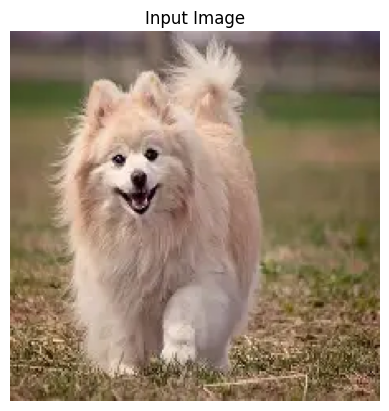

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step

Top Predictions:
1. Samoyed - 75.44%
2. Pomeranian - 14.56%
3. chow - 5.26%


In [70]:
def predict_image(img_path, top_k=3):
    """
    Predict the class of an image using pretrained ResNet50.
    """

    if not os.path.exists(img_path):
        print("Image not found:", img_path)
        return

    # Load image
    img = keras.utils.load_img(img_path, target_size=(224, 224))

    # Display image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # Convert image to array
    x = keras.utils.img_to_array(img)

    # Add batch dimension: (224,224,3) -> (1,224,224,3)
    x = np.expand_dims(x, axis=0)

    # Preprocess for ResNet50
    x = preprocess_input(x)
# Predict
    preds = model.predict(x)

    # Decode predictions
    results = decode_predictions(preds, top=top_k)[0]

    print("\nTop Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} - {probability*100:.2f}%")


# Example usage
img_path = '/OIP (1).webp'
predict_image(img_path, top_k=3)

Saving tshirt.jpg to tshirt.jpg
Uploaded file: tshirt.jpg


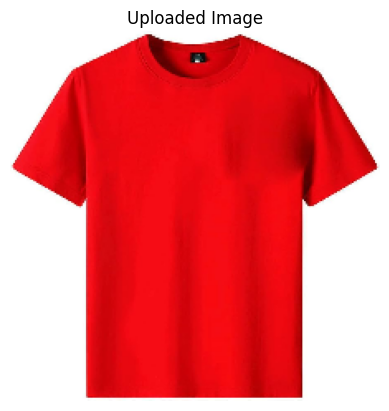

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Top Predictions:
1. jersey - 99.10%
2. pajama - 0.42%
3. sweatshirt - 0.10%
4. maillot - 0.09%
5. wool - 0.05%
6. vestment - 0.03%
7. velvet - 0.03%
8. academic_gown - 0.03%
9. kimono - 0.02%
10. poncho - 0.01%


In [51]:
from google.colab import files
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

model =  ResNet50(weights="imagenet")

def predict_image(img_path, top_k=3):
    img = keras.utils.load_img(img_path, target_size=(224, 224))

    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()

    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    results = decode_predictions(preds, top=top_k)[0]

    print("Top Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} - {probability*100:.2f}%")
uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)
    predict_image(filename, top_k=10)



Saving Screenshot 2026-06-05 193120.png to Screenshot 2026-06-05 193120.png


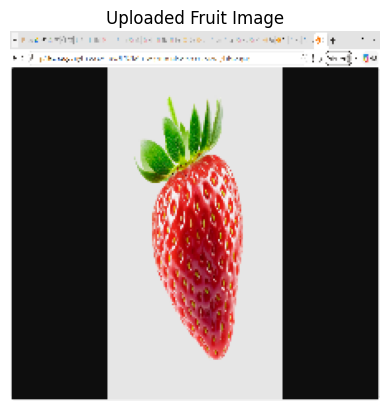

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step

Top Predictions:
1. strawberry --> 99.99%
2. banana --> 0.00%
3. pineapple --> 0.00%


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
from google.colab import files

# Load pretrained model
model = ResNet50(weights='imagenet')

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():

    # Load image
    img = keras.utils.load_img(filename, target_size=(224,224))

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Fruit Image")
    plt.show()

    # Convert image to array
    x = keras.utils.img_to_array(img)

    # Add batch dimension
    x = np.expand_dims(x, axis=0)

    # Preprocess image
    x = preprocess_input(x)

    # Predict
    preds = model.predict(x)
    # Predict
    preds = model.predict(x)

    # Decode predictions
    results = decode_predictions(preds, top=3)[0]

    print("\nTop Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} --> {probability*100:.2f}%")


**Vehicle Recognition using MobileNetV2

Saving download.webp to download.webp


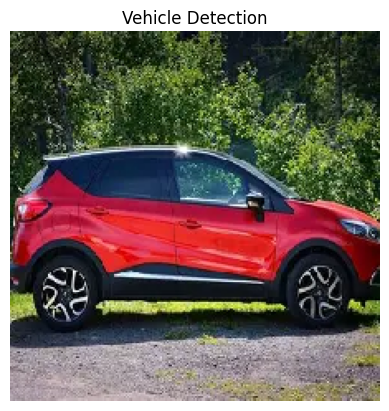

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Predictions:
1. minivan --> 74.20%
2. beach_wagon --> 3.46%
3. car_wheel --> 1.76%


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.mobilenet_v2 import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from google.colab import files

# Load pretrained model
model = MobileNetV2(weights='imagenet')

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():

    img = keras.utils.load_img(filename, target_size=(224,224))

    plt.imshow(img)
    plt.axis("off")
    plt.title("Vehicle Detection")
    plt.show()

    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)

    results = decode_predictions(preds, top=3)[0]

    print("\nPredictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} --> {probability*100:.2f}%")


Saving th.webp to th.webp


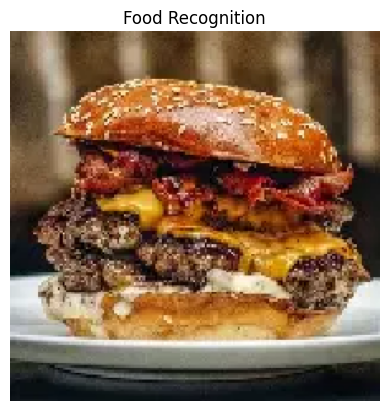

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Food Predictions:
1. cheeseburger --> 62.57%
2. meat_loaf --> 5.32%
3. plate --> 0.99%


In [56]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.efficientnet import EfficientNetB0
from keras.applications.efficientnet import preprocess_input, decode_predictions
from google.colab import files

# Load pretrained model
model = EfficientNetB0(weights='imagenet')

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():

    img = keras.utils.load_img(filename, target_size=(224,224))

    plt.imshow(img)
    plt.axis("off")
    plt.title("Food Recognition")
    plt.show()

    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)

    results = decode_predictions(preds, top=3)[0]

    print("\nFood Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} --> {probability*100:.2f}%")